In [1]:
import pandas as pd
import os,re,glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


dates={"CW1A": "2024-07-25", "CW2A": "2024-08-01", "CW3A": "2024-08-07",
 "EXPUPS1A": "2024-07-25", "EXPUPS2A": "2024-08-01", "EXPUPS3A": "2024-08-07",
 "EXPMDS1B": "2024-07-25", "EXPMDS2B": "2024-08-01", 
 "EXPDWS1C": "2024-07-25", "EXPDWS2C": "2024-08-01", "EXPDWS3C": "2024-08-07",
 "PETUPS1A": "2024-07-25", "PETUPS2A": "2024-08-01", "PETUPS3A": "2024-08-07",
 
       "PETDWS2B": "2024-08-01", 
       "PETDWS2C": "2024-08-01", 
       
 "MBUPS1A": "2024-07-25", "MBUPS2A": "2024-08-01", "MBUPS3A": "2024-08-07",
 "MBMDS1B": "2024-07-25", "MBMDS2B": "2024-08-01", "MBMDS3B": "2024-08-07",
 "MBDWS1C": "2024-07-25", "MBDDWS2C": "2024-08-01", "MBDWS3C": "2024-08-07",
 "AJBUPS1A": "2024-07-25", "AJBUPS2A": "2024-08-01", "AJBUPS3A": "2024-08-07",
  "AJBMDS2B": "2024-08-01", "AJBMDS3B": "2024-08-07",
 "AJBDWS1C": "2024-07-25", "AJBDWS2C": "2024-08-01", "AJBDWS3C": "2024-08-07",
 "AJA1A": "2024-07-25", "AJA2A": "2024-08-01", "AJA3A": "2024-08-07"}




coords={"CW":(6.522984,3.310817), 
 "EXP":(6.529435,3.316108),
 "PET":(6.540710,3.319277),
 "MB":(6.530166,3.316193),
 "MBD":(6.530166,3.316193),
 "AJB":(6.544360, 3.318868),
 "AJA":(6.537347,3.323543)}


MT=[]

for f in glob.glob("*.report.txt"):
    if "NE.AACMFLCHV" not in f and "NTC" not in f:
        df=pd.read_csv(f,sep="\t", skiprows=2)
        df["sample"]=re.sub(".AACMFLCHV.1.cleaned_bbdukclean.report.txt", "", f)

        df['taxName'] = df['taxName'].str.strip()
        
        bacteria_idx = df.index[df['taxName'] == 'Bacteria']
    
        if len(bacteria_idx) == 0:
            subset = pd.DataFrame() 
        else:
            start_idx = bacteria_idx[0]
        
            other_idx = df.index[(df['taxName'] == 'Eukaryota') & (df.index > start_idx)]
        
            if len(other_idx) > 0:
                end_idx = other_idx[0]
            else:
                end_idx = df.index[-1]  # fallback to last row
        
            bactsubset = df.loc[start_idx:end_idx-1]
            
            MT.append(bactsubset)
        
MTori=pd.concat(MT)

## https://link.springer.com/article/10.1186/s13059-018-1568-0


In [2]:

bactdf=MTori[MTori["taxName"]=="Bacteria"]
bactd=dict(zip(bactdf["sample"], bactdf["reads"]))

for fam in ['Aeromonas', 'Pseudomonas', 'Aliarcobacter', 'Klebsiella', 'Escherichia', 'Streptococcus']:
    famdf=MTori[(MTori["rank"]=="genus") & (MTori["taxName"]==fam) ]
    famdf["bacterial_reads"]=famdf["sample"].map(bactd)
    famdf["prop"]=(famdf["reads"]/famdf["bacterial_reads"])*100
    print(fam,famdf["prop"].median())

Aeromonas 0.6774743244271042
Pseudomonas 2.5740963804913766
Aliarcobacter 2.3317621429997195
Klebsiella 0.1472929417303444
Escherichia 0.10337073451078257
Streptococcus 0.05811389552098722


In [3]:
MT=MTori[(MTori["reads"]>=10) & (MTori["kmers"]>=660)]

In [4]:
tdf=pd.read_csv("read_counts_seqkit.csv")
tdf["sample"]=tdf["file"].str.replace(".AACMFLCHV.1.cleaned_bbdukclean_R1.fastq.gz", "")
tdf["millions"]=round(tdf["num_seqs"]/1000000, 0)
tdf["kmerthreshold"]=tdf["millions"]*660

tdf["kmerthreshold_strict"]=tdf["millions"]*1300

kmer=dict(zip(tdf["sample"], tdf["kmerthreshold"]))
kmer_strict_d=dict(zip(tdf["sample"], tdf["kmerthreshold_strict"]))


In [5]:
len(MT["sample"].unique())

35

In [7]:
len(MT[MT["rank"]=="family"]["taxName"].unique())

291

In [8]:
len(MT[MT["rank"]=="genus"]["taxName"].unique())

762

In [9]:
len(MT[MT["rank"]=="species"]["taxName"].unique())

1888

In [10]:
sdf=MT[MT["rank"]=="species"]

sdf["kmerthreshold"]=sdf["sample"].map(kmer)
sdf["kmerthreshold_strict"]=sdf["sample"].map(kmer_strict_d)
sdf["pass"]=sdf["kmers"]> sdf["kmerthreshold"]
sdf["pass_strict"]=sdf["kmers"]> sdf["kmerthreshold_strict"]

In [12]:
taxid=pd.read_csv("combined_taxids_DD.txt", header=None)[0].to_list()
cz=pd.read_csv("CZIDpathogens.txt", header=None)[0].to_list()
pathogen_taxids=taxid+cz
sdf=sdf[sdf['taxID'].isin(pathogen_taxids)]

In [13]:
MT_ddf=pd.read_csv("taxid_family_genus_species.csv")
gd=dict(zip(MT_ddf['taxid'],MT_ddf['genus']))
sd=dict(zip(MT_ddf['taxid'],MT_ddf['species']))
fd=dict(zip(MT_ddf['taxid'],MT_ddf['family']))
sdf["genus"]=sdf["taxID"].map(gd)
sdf["family"]=sdf["taxID"].map(fd)
sdf["species"]=sdf["taxID"].map(sd)

In [14]:
print(len(sdf[sdf["genus"].isna()]))
print(len(sdf[sdf["family"].isna()]))
print(len(sdf[sdf["species"].isna()]))

5
10
5


In [15]:
len(sdf["family"].unique())

42

In [16]:
len(sdf["genus"].unique())

68

In [17]:
len(sdf["species"].unique())

139

In [19]:
genera_per_sample = sdf.dropna(subset=["genus"]).groupby("sample")["genus"].nunique().reset_index(name="n_genera")
print(genera_per_sample["n_genera"].min())
print(genera_per_sample["n_genera"].max())

13
65


In [20]:
sdf.groupby("genus")["reads"].sum().sort_values(ascending=False).head(10)

genus
Aeromonas          1124881
Pseudomonas         972745
Aliarcobacter       644298
Klebsiella          382028
Streptococcus       252671
Ectopseudomonas     249264
Escherichia         224183
Burkholderia        205748
Vibrio              189885
Acinetobacter        97432
Name: reads, dtype: int64

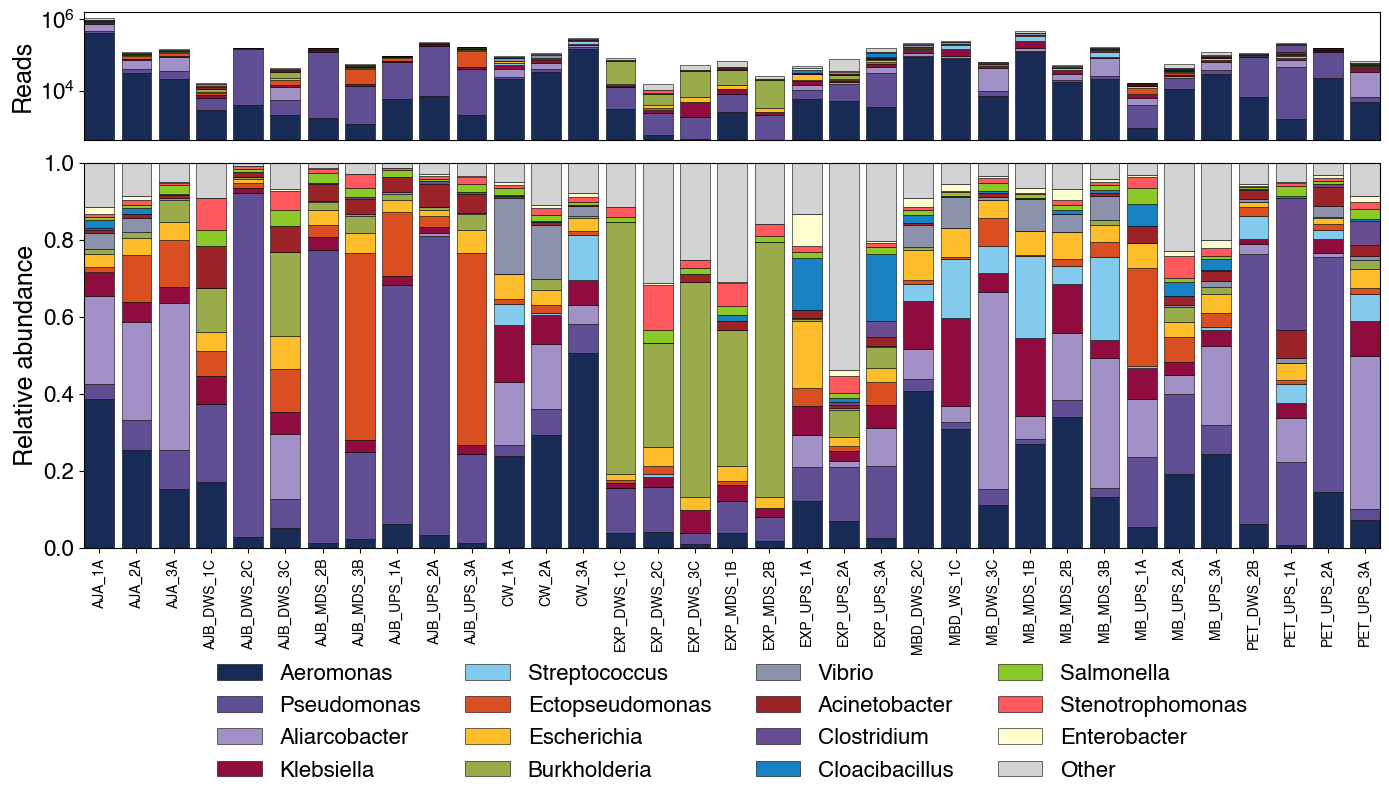

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

gdf = sdf.groupby(['sample', 'genus'], as_index=False)['reads'].sum()

top_genera = (gdf.groupby('genus')['reads'].sum().sort_values(ascending=False).head(15).index)

gdf['genus_plot'] = np.where( gdf['genus'].isin(top_genera),gdf['genus'],'Other')
gdf = gdf.groupby(['sample', 'genus_plot'], as_index=False)['reads'].sum()

gdf['rel_abundance'] = gdf.groupby('sample')['reads'].transform(lambda x: x / x.sum())


piv_rel = gdf.pivot(index='sample',columns='genus_plot',values='rel_abundance').fillna(0)
piv_abs = gdf.pivot(index='sample',columns='genus_plot',values='reads').fillna(0)
ordered_cols = [g for g in top_genera if g in piv_rel.columns]

if 'Other' in piv_rel.columns:
    ordered_cols.append('Other')

piv_rel = piv_rel[ordered_cols]
piv_abs = piv_abs.reindex(index=piv_rel.index,columns=piv_rel.columns)


all_colors = [ '#182b55', '#5f4e94','#a291c7', '#900c3f', '#82cbec', '#d94f21', '#febd2b', '#9aab4b',
             "#8C92AC","#9b2226", "#6a4c93",   "#1982c4",  "#8ac926",  "#ff595e",  "#FFFDD0", "#ffca3a",  "#8338ec", "#3a86ff"]

cmap = {}
for i, genus in enumerate(ordered_cols):
    if genus != 'Other':
        cmap[genus] = all_colors[i]

cmap['Other'] = '#D3D3D3'

fig, (ax_top, ax_bottom) = plt.subplots( 2, 1, figsize=(14, 8),  sharex=True,  gridspec_kw={"height_ratios": [1, 3]})

x = np.arange(len(piv_rel.index))

bottom = np.zeros(len(piv_abs.index))

for genus in piv_abs.columns:
    vals = piv_abs[genus].values

    ax_top.bar( x, vals, bottom=bottom,color=cmap[genus], edgecolor='black', linewidth=0.4)

    bottom += vals

ax_top.set_yscale('log')
ax_top.set_ylabel('Reads', fontsize=18)

ax_top.tick_params(
    axis='x',
    which='both',
    bottom=False,
    labelbottom=False
)

ax_top.margins(x=0)

bottom = np.zeros(len(piv_rel.index))

for genus in piv_rel.columns:
    vals = piv_rel[genus].values

    ax_bottom.bar( x, vals,bottom=bottom,color=cmap[genus],  label=genus, edgecolor='black',linewidth=0.4)

    bottom += vals

ax_bottom.set_ylabel('Relative abundance', fontsize=18)
ax_bottom.set_ylim(0, 1)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(piv_rel.index, rotation=90)
ax_bottom.tick_params(axis="y", labelsize=16)
ax_top.tick_params(axis="y", labelsize=16)

ax_bottom.margins(x=0)

ax_bottom.legend( loc='upper center',bbox_to_anchor=(0.5, -0.25), ncol=4,frameon=False, fontsize=16)

plt.subplots_adjust( hspace=0.05, bottom=0.3)

plt.tight_layout()


plt.show()

In [22]:
sdf.groupby("genus")["reads"].sum().sort_values(ascending=False).head(15)

genus
Aeromonas           1124881
Pseudomonas          972745
Aliarcobacter        644298
Klebsiella           382028
Streptococcus        252671
Ectopseudomonas      249264
Escherichia          224183
Burkholderia         205748
Vibrio               189885
Acinetobacter         97432
Clostridium           92900
Cloacibacillus        74609
Salmonella            67821
Stenotrophomonas      64728
Enterobacter          58057
Name: reads, dtype: int64

In [23]:
check=sdf.groupby("species")["reads"].sum().sort_values(ascending=False)
check=check.reset_index()

In [24]:
pd.DataFrame(check)[0:5]

,species,reads
0,Aeromonas caviae,679329
1,Aliarcobacter butzleri,644298
2,Pseudomonas fluorescens,395304
3,Pseudomonas aeruginosa,289358
4,Ectopseudomonas mendocina,249264


In [25]:
check[check["species"].str.contains("Bacillus")]

,species,reads
85,Bacillus cereus,2098
113,Bacillus thuringiensis,502


In [26]:
low_focus=["Streptococcus suis", "Klebsiella pneumoniae", "Salmonella enterica", "Vibrio parahaemolyticus", "Clostridium perfringens", "Shigella flexneri", 
           "Yersinia enterocolitica", "Aliarcobacter butzleri"]

high_focus=[ "Burkholderia pseudomallei", "Vibrio cholerae", "Clostridium botulinum", "Bordetella parapertussis"]


In [27]:
MTori["kmerthreshold"]=MTori["sample"].map(kmer)
MTori["kmerthreshold_strict"]=MTori["sample"].map(kmer_strict_d)
MTori["pass"]=MTori["kmers"]> MTori["kmerthreshold"]
MTori["pass_strict"]=MTori["kmers"]> MTori["kmerthreshold_strict"]

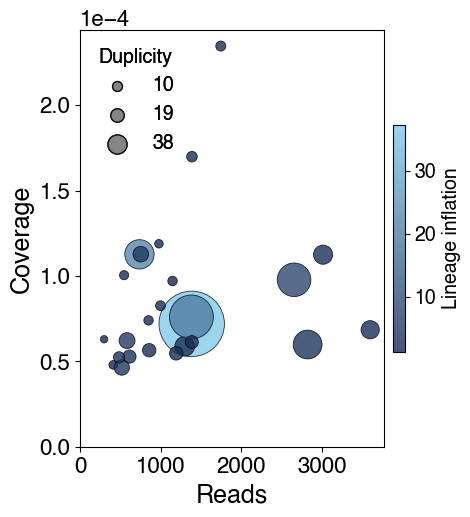

In [29]:

pdf=MTori[(MTori["taxName"].str.contains("Burkholderia pseudomallei")) & (MTori["kmers"]>=700)]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf["reads"] = pd.to_numeric(pdf["reads"], errors="coerce")
pdf["taxReads"] = pd.to_numeric(pdf["taxReads"], errors="coerce")
pdf["cov"] = pd.to_numeric(pdf["cov"], errors="coerce")
pdf["kmers"] = pd.to_numeric(pdf["kmers"], errors="coerce")
pdf["dup"] = pd.to_numeric(pdf["dup"], errors="coerce")
pdf["kmers_per_taxRead"] = pdf["kmers"] / pdf["taxReads"]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]


sizes = pdf["dup"] * 5


vmin = pdf["lineage_inflation"].min()
vmax = pdf["lineage_inflation"].max()

legend_dups = [ pdf["dup"].quantile(0.25), pdf["dup"].median(),pdf["dup"].quantile(0.75)]


custom_cmap = LinearSegmentedColormap.from_list("custom_cmap",["#182b55", '#82cbec'])


fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"], pdf["cov"],s=sizes, c=pdf["lineage_inflation"],  cmap=custom_cmap,  vmin=vmin, vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Coverage", fontsize=18)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar( sc, ax=ax, fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)


handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper left",
    fontsize=14,
    title_fontsize=14
)

ax.add_artist(size_legend)
plt.tight_layout()

ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)


plt.show()

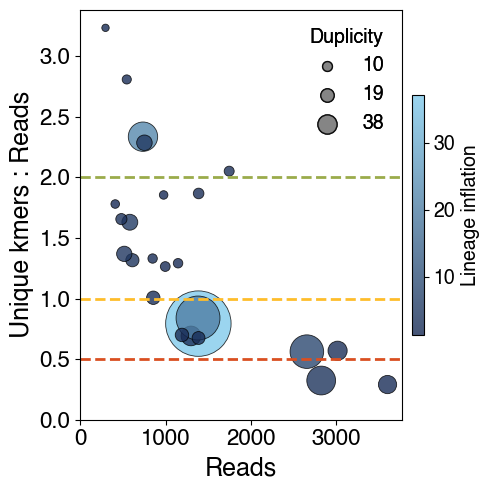

In [31]:

fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"],pdf["kmers_per_taxRead"], s=sizes,c=pdf["lineage_inflation"], cmap=custom_cmap, vmin=vmin,vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.axhline(0.5,color="#d94f21",linestyle="--", linewidth=2,label="0.5x")
ax.axhline(1,color="#febd2b",linestyle="--",linewidth=2,label="1x")
ax.axhline(2,color="#9aab4b",linestyle="--", linewidth=2,label="2x")

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Unique kmers : Reads", fontsize=18)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar(sc,ax=ax,fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)

handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper right",
    fontsize=14,
    title_fontsize=14
)
ax.add_artist(size_legend)
ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)
plt.tight_layout()

plt.show()

In [32]:
pdf=MTori[(MTori["taxName"].str.contains("Vibrio cholerae")) & (MTori["kmers"]>=700)]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in pdf["sample"]]
pdf["date"]=[dates[re.sub("_", "", x)] for x in pdf["sample"]]
print(len(pdf["sample"].unique()))
print(len(pdf["canal"].unique()))
print(len(pdf["date"].unique()))

26
6
3


In [33]:
check=MTori[(MTori["taxName"].str.contains("Vibrio cholerae")) & (MTori["kmers"]>=700) & (MTori["pass_strict"]==True)]
check["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in check["sample"]]
check["date"]=[dates[re.sub("_", "", x)] for x in check["sample"]]
print(len(check["sample"].unique()))
print(len(check["canal"].unique()))
print(len(check["date"].unique()))



3
2
1


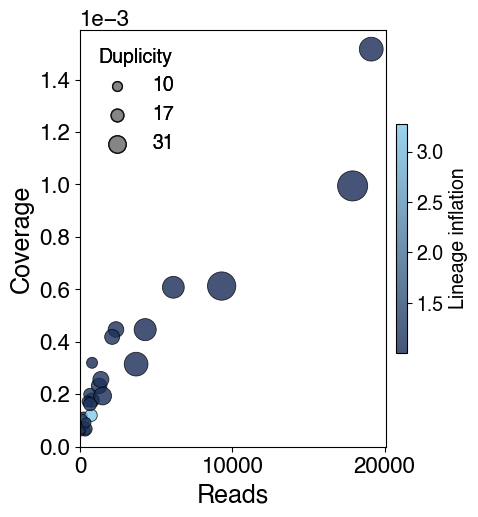

In [35]:
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf["reads"] = pd.to_numeric(pdf["reads"], errors="coerce")
pdf["taxReads"] = pd.to_numeric(pdf["taxReads"], errors="coerce")
pdf["cov"] = pd.to_numeric(pdf["cov"], errors="coerce")
pdf["kmers"] = pd.to_numeric(pdf["kmers"], errors="coerce")
pdf["dup"] = pd.to_numeric(pdf["dup"], errors="coerce")
pdf["kmers_per_taxRead"] = pdf["kmers"] / pdf["taxReads"]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]


sizes = pdf["dup"] * 5


vmin = pdf["lineage_inflation"].min()
vmax = pdf["lineage_inflation"].max()

legend_dups = [ pdf["dup"].quantile(0.25), pdf["dup"].median(),pdf["dup"].quantile(0.75)]


custom_cmap = LinearSegmentedColormap.from_list("custom_cmap",["#182b55", '#82cbec'])


fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"], pdf["cov"],s=sizes, c=pdf["lineage_inflation"],  cmap=custom_cmap,  vmin=vmin, vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Coverage", fontsize=18)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar( sc, ax=ax, fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)


handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper left",
    fontsize=14,
    title_fontsize=14
)

ax.add_artist(size_legend)
plt.tight_layout()

ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)


plt.show()

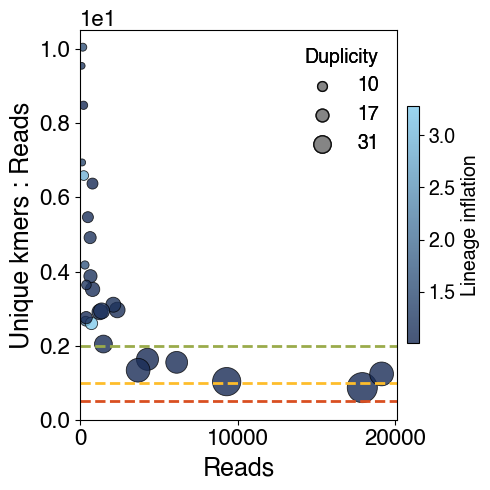

In [36]:

fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"],pdf["kmers_per_taxRead"], s=sizes,c=pdf["lineage_inflation"], cmap=custom_cmap, vmin=vmin,vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.axhline(0.5,color="#d94f21",linestyle="--", linewidth=2,label="0.5x")
ax.axhline(1,color="#febd2b",linestyle="--",linewidth=2,label="1x")
ax.axhline(2,color="#9aab4b",linestyle="--", linewidth=2,label="2x")

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Unique kmers : Reads", fontsize=18)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar(sc,ax=ax,fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)

handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper right",
    fontsize=14,
    title_fontsize=14
)
ax.add_artist(size_legend)
ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)
plt.tight_layout()

plt.show()

In [38]:
pdf=MTori[(MTori["taxName"].str.contains("Salmonella enterica")) & (MTori["kmers"]>=700)]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf=pdf[pdf["rank"]=="species"]
pdf["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in pdf["sample"]]
pdf["date"]=[dates[re.sub("_", "", x)] for x in pdf["sample"]]
print(len(pdf["sample"].unique()))
print(len(pdf["canal"].unique()))
print(len(pdf["date"].unique()))


35
6
3


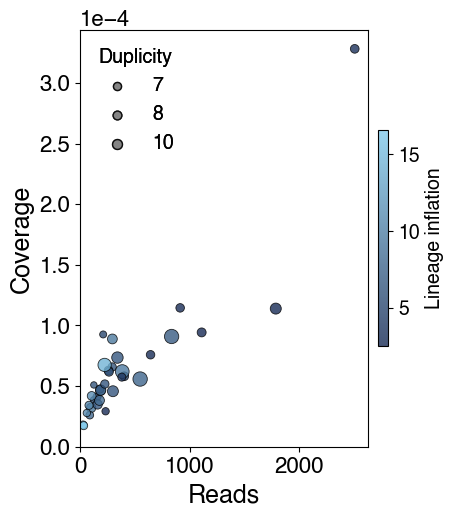

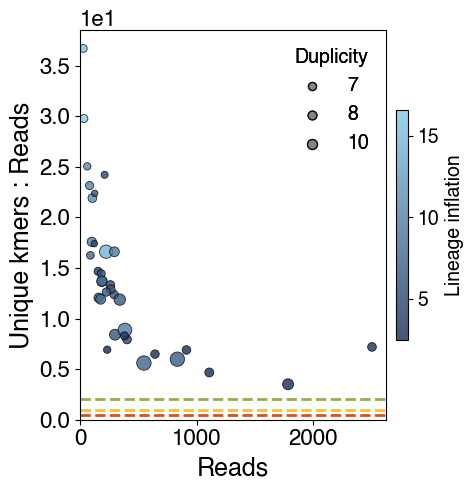

In [39]:

pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf["reads"] = pd.to_numeric(pdf["reads"], errors="coerce")
pdf["taxReads"] = pd.to_numeric(pdf["taxReads"], errors="coerce")
pdf["cov"] = pd.to_numeric(pdf["cov"], errors="coerce")
pdf["kmers"] = pd.to_numeric(pdf["kmers"], errors="coerce")
pdf["dup"] = pd.to_numeric(pdf["dup"], errors="coerce")
pdf["kmers_per_taxRead"] = pdf["kmers"] / pdf["taxReads"]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]


sizes = pdf["dup"] * 5


vmin = pdf["lineage_inflation"].min()
vmax = pdf["lineage_inflation"].max()

legend_dups = [ pdf["dup"].quantile(0.25), pdf["dup"].median(),pdf["dup"].quantile(0.75)]


custom_cmap = LinearSegmentedColormap.from_list("custom_cmap",["#182b55", '#82cbec'])


fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"], pdf["cov"],s=sizes, c=pdf["lineage_inflation"],  cmap=custom_cmap,  vmin=vmin, vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Coverage", fontsize=18)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar( sc, ax=ax, fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)


handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper left",
    fontsize=14,
    title_fontsize=14
)

ax.add_artist(size_legend)
plt.tight_layout()

ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)


plt.show()



fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"],pdf["kmers_per_taxRead"], s=sizes,c=pdf["lineage_inflation"], cmap=custom_cmap, vmin=vmin,vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.axhline(0.5,color="#d94f21",linestyle="--", linewidth=2,label="0.5x")
ax.axhline(1,color="#febd2b",linestyle="--",linewidth=2,label="1x")
ax.axhline(2,color="#9aab4b",linestyle="--", linewidth=2,label="2x")

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Unique kmers : Reads", fontsize=18)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar(sc,ax=ax,fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)

handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper right",
    fontsize=14,
    title_fontsize=14
)
ax.add_artist(size_legend)
ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)
plt.tight_layout()

plt.show()

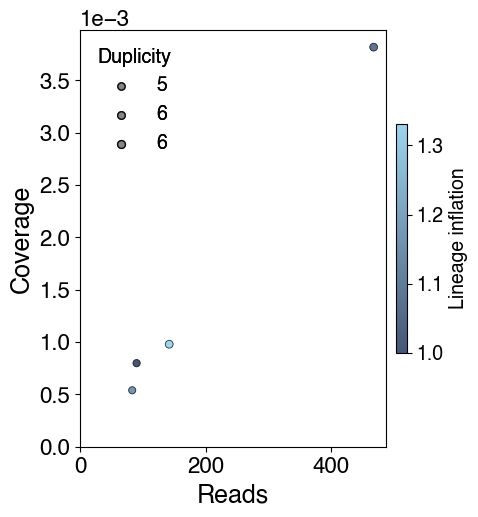

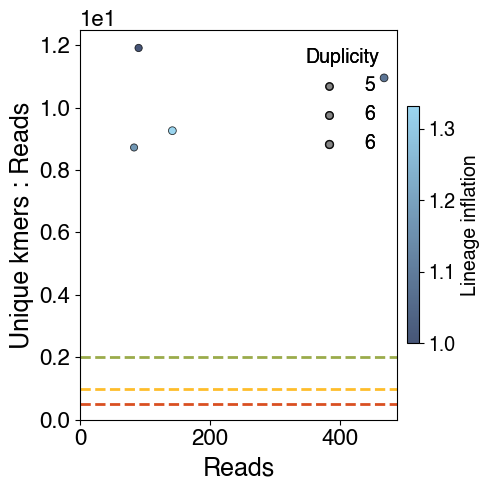

In [40]:
pdf=MTori[(MTori["taxName"].str.contains("Shigella flex")) & (MTori["kmers"]>=700)]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf=pdf[pdf["rank"]=="species"]


pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf["reads"] = pd.to_numeric(pdf["reads"], errors="coerce")
pdf["taxReads"] = pd.to_numeric(pdf["taxReads"], errors="coerce")
pdf["cov"] = pd.to_numeric(pdf["cov"], errors="coerce")
pdf["kmers"] = pd.to_numeric(pdf["kmers"], errors="coerce")
pdf["dup"] = pd.to_numeric(pdf["dup"], errors="coerce")
pdf["kmers_per_taxRead"] = pdf["kmers"] / pdf["taxReads"]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]


sizes = pdf["dup"] * 5


vmin = pdf["lineage_inflation"].min()
vmax = pdf["lineage_inflation"].max()

legend_dups = [ pdf["dup"].quantile(0.25), pdf["dup"].median(),pdf["dup"].quantile(0.75)]


custom_cmap = LinearSegmentedColormap.from_list("custom_cmap",["#182b55", '#82cbec'])


fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"], pdf["cov"],s=sizes, c=pdf["lineage_inflation"],  cmap=custom_cmap,  vmin=vmin, vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Coverage", fontsize=18)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar( sc, ax=ax, fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)


handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper left",
    fontsize=14,
    title_fontsize=14
)

ax.add_artist(size_legend)
plt.tight_layout()

ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)


plt.show()



fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"],pdf["kmers_per_taxRead"], s=sizes,c=pdf["lineage_inflation"], cmap=custom_cmap, vmin=vmin,vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.axhline(0.5,color="#d94f21",linestyle="--", linewidth=2,label="0.5x")
ax.axhline(1,color="#febd2b",linestyle="--",linewidth=2,label="1x")
ax.axhline(2,color="#9aab4b",linestyle="--", linewidth=2,label="2x")

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Unique kmers : Reads", fontsize=18)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar(sc,ax=ax,fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)

handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper right",
    fontsize=14,
    title_fontsize=14
)
ax.add_artist(size_legend)
ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)
plt.tight_layout()

plt.show()

In [48]:
pdf=MTori[(MTori["taxName"].str.contains("Neisseria menin")) & (MTori["kmers"]>=700)]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf=pdf[pdf["rank"]=="species"]
pdf

,%,reads,taxReads,kmers,dup,cov,taxID,rank,taxName,sample,kmerthreshold,kmerthreshold_strict,pass,pass_strict,lineage_inflation
4094,0.00205,827,710,717,23.2,0.00017,487,species,Neisseria meningitidis,AJA_1A,26400.0,52000.0,False,False,1.164789


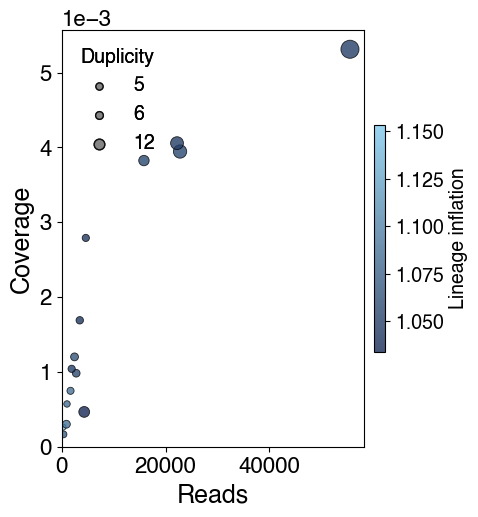

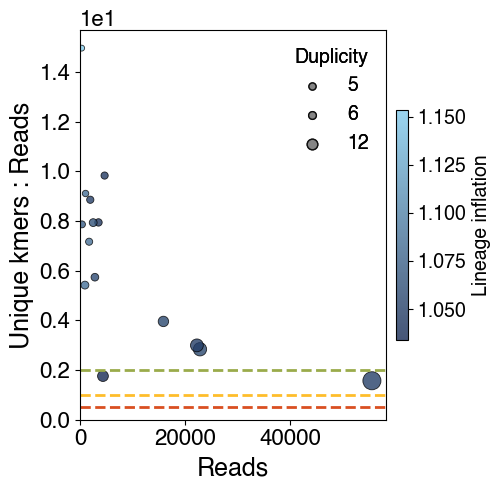

In [41]:
pdf=MTori[(MTori["taxName"].str.contains("Streptococcus suis")) & (MTori["kmers"]>=700)]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf=pdf[pdf["rank"]=="species"]




pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf["reads"] = pd.to_numeric(pdf["reads"], errors="coerce")
pdf["taxReads"] = pd.to_numeric(pdf["taxReads"], errors="coerce")
pdf["cov"] = pd.to_numeric(pdf["cov"], errors="coerce")
pdf["kmers"] = pd.to_numeric(pdf["kmers"], errors="coerce")
pdf["dup"] = pd.to_numeric(pdf["dup"], errors="coerce")
pdf["kmers_per_taxRead"] = pdf["kmers"] / pdf["taxReads"]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]


sizes = pdf["dup"] * 5


vmin = pdf["lineage_inflation"].min()
vmax = pdf["lineage_inflation"].max()

legend_dups = [ pdf["dup"].quantile(0.25), pdf["dup"].median(),pdf["dup"].quantile(0.75)]


custom_cmap = LinearSegmentedColormap.from_list("custom_cmap",["#182b55", '#82cbec'])


fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"], pdf["cov"],s=sizes, c=pdf["lineage_inflation"],  cmap=custom_cmap,  vmin=vmin, vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Coverage", fontsize=18)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar( sc, ax=ax, fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)


handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper left",
    fontsize=14,
    title_fontsize=14
)

ax.add_artist(size_legend)
plt.tight_layout()

ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)


plt.show()



fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter( pdf["taxReads"],pdf["kmers_per_taxRead"], s=sizes,c=pdf["lineage_inflation"], cmap=custom_cmap, vmin=vmin,vmax=vmax,edgecolor="black",linewidth=0.6,alpha=0.8)

ax.axhline(0.5,color="#d94f21",linestyle="--", linewidth=2,label="0.5x")
ax.axhline(1,color="#febd2b",linestyle="--",linewidth=2,label="1x")
ax.axhline(2,color="#9aab4b",linestyle="--", linewidth=2,label="2x")

ax.set_xlabel("Reads", fontsize=18)
ax.set_ylabel("Unique kmers : Reads", fontsize=18)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar(sc,ax=ax,fraction=0.035,pad=0.03, shrink=0.75)

cbar.set_label("Lineage inflation", fontsize=14)
cbar.ax.tick_params(labelsize=14)

handles = [
    ax.scatter(
        [],
        [],
        s=d * size_multiplier,
        color="grey",
        edgecolor="black",
        alpha=0.8
    )
    for d in legend_dups
]

size_legend = ax.legend(
    handles,
    [f"{d:.0f}" for d in legend_dups],
    title="Duplicity",
    frameon=False,
    scatterpoints=1,
    loc="upper right",
    fontsize=14,
    title_fontsize=14
)
ax.add_artist(size_legend)
ax.yaxis.get_offset_text().set_fontsize(16)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.tick_params(axis="both", labelsize=16)
plt.tight_layout()

plt.show()

In [76]:
low_focus=["Streptococcus suis", "Klebsiella pneumoniae", "Salmonella enterica", "Vibrio parahaemolyticus", "Clostridium perfringens", "Shigella flexneri", 
           "Yersinia enterocolitica", "Aliarcobacter butzleri"]
high_focus=[ "Burkholderia pseudomallei", "Vibrio cholerae", "Clostridium botulinum", "Bordetella parapertussis"]

alles=["Burkholderia pseudomallei", "Vibrio cholerae", "Clostridium botulinum", "Bordetella parapertussis", "Streptococcus suis", "Klebsiella pneumoniae", "Salmonella enterica", "Vibrio parahaemolyticus", "Clostridium perfringens", "Shigella flexneri", 
           "Yersinia enterocolitica", "Aliarcobacter butzleri", "Neisseria meningitidis","Streptococcus parasuis"]


hdf=sdf[sdf["taxName"].isin(alles)]
sample_counts = (hdf.groupby("taxName")["sample"].count().reset_index(name="Relaxed"))
passdf=hdf[hdf["pass"]==True]
sample_counts = (passdf.groupby("taxName")["sample"].count().reset_index(name="Balanced"))
passd_strict=hdf[hdf["pass_strict"]==True]
sample_counts = (passd_strict.groupby("taxName")["sample"].count().reset_index(name="Strict"))


KU_s=pd.read_csv('KUmin_highbacteriadetection_counts.csv')
KU=pd.read_csv('KUmax_highbacteriadetection_counts.csv')
KU_stricter=pd.read_csv('KUmax_highbacteriavalidation_counts.csv')
BC=pd.read_csv("BC_highbacteriadetection_counts.csv")

BC=BC.rename(columns={"species":"taxName"})

merged_df = (BC.merge(KU_s, on="taxName", how="outer").merge(KU, on="taxName", how="outer").merge(KU_stricter, on="taxName", how="outer").fillna(0))
merged_df = merged_df.reset_index(drop=True)


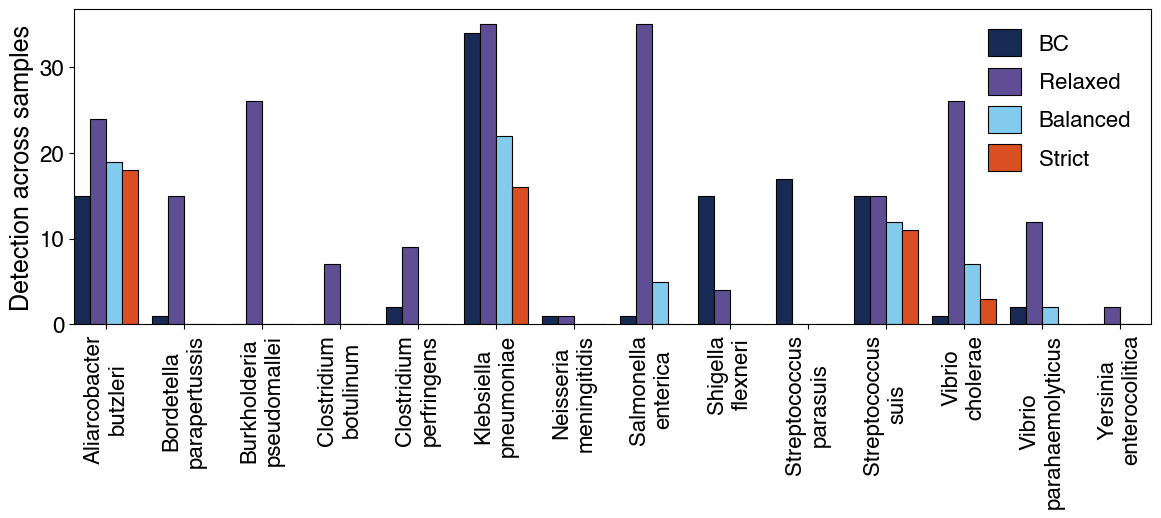

In [93]:
import matplotlib.pyplot as plt
import numpy as np

merged_df = merged_df.sort_values("taxName")
xlabs = merged_df["taxName"].str.replace(" ", "\n", regex=False)

ww = 0.22
gg = 0.2  
x = np.arange(len(merged_df["taxName"])) * (4 * ww + gg)
fig, ax = plt.subplots(figsize=(12,4))

ax.bar( x, merged_df["BC"], ww,label="BC", color="#182b55",edgecolor="black",linewidth=0.8)
ax.bar(x + ww, merged_df["Relaxed"], ww, label="Relaxed",color="#5f4e94",edgecolor="black", linewidth=0.8)
ax.bar( x + 2 * ww, merged_df["Balanced"],ww,label="Balanced",color="#82cbec", edgecolor="black", linewidth=0.8)
ax.bar( x + 3 * ww, merged_df["Strict"],ww, label="Strict", color="#d94f21", edgecolor="black",linewidth=0.8)

ax.set_xlabel("")
ax.set_ylabel("Detection across samples", fontsize=18)

ax.set_xticks(x + 1.5 * ww)
ax.set_xticklabels(xlabs, fontsize=16)

ax.legend( frameon=False,fontsize=16, handlelength=1.5, handleheight=1.5,)
ax.margins(x=0)
plt.tight_layout()

ax.tick_params(axis="x", labelrotation=90)
ax.tick_params(axis="both", labelsize=16)

plt.show()

In [57]:
# print(len(sdf[(sdf["name"].str.contains(spec)) & (sdf["pass"]==True)]["sample"].unique()))
# sdf[(sdf["name"].str.contains(spec)) & (sdf["pass"]==True)]

In [58]:
# print(len(sdf[(sdf["name"].str.contains(spec)) & (sdf["pass_strict"]==True)]["sample"].unique()))
# sdf[(sdf["name"].str.contains(spec)) & (sdf["pass_strict"]==True)]

In [59]:
BC_reads=pd.read_csv("BC_bacteria_readcounts.csv")
BC_reads=BC_reads[["sample", "reads", "species"]].rename(columns={"reads":"BC"})
KU_reads=sdf[["sample", "taxReads", "species"]].rename(columns={"taxReads":"KU"})
merged_df = BC_reads.merge(KU_reads, on=["species", "sample"], how="outer").fillna(0)
merged_df = merged_df.reset_index(drop=True)
merged_df=merged_df[merged_df["species"].isin(alles)]
merged_df=merged_df[~merged_df["species"].isin(["Aliarcobacter butzleri"])]

In [60]:
merged_df["BC"]=merged_df["BC"]*2


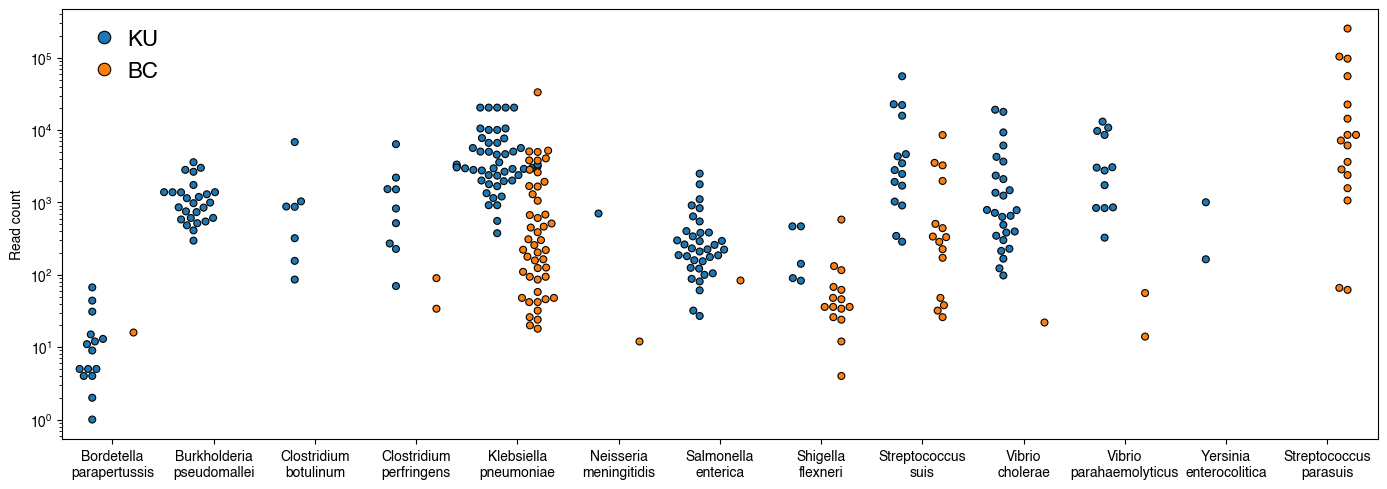

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plot_df = merged_df[["species", "KU", "BC"]].copy()
plot_df["species_label"] = plot_df["species"].str.replace(" ", "\n", n=1, regex=False)

long_df = plot_df.melt(id_vars=["species", "species_label"], value_vars=["KU", "BC"], var_name="source",value_name="value")

long_df = long_df[long_df["value"] > 0].copy()

plt.figure(figsize=(14, 5))

ax = sns.swarmplot(data=long_df, x="species_label",y="value",hue="source",dodge=True,size=5,edgecolor="black",linewidth=0.8)

plt.legend( title=None,   frameon=False,  fontsize=16, markerscale=1.8,handletextpad=0.05)

plt.yscale("log")
plt.xticks(rotation=0, ha="center")

plt.xlabel("")
plt.ylabel("Read count")
plt.tight_layout()

plt.show()